# Figures for Harding and Gasque (2026) paper: 

## "Electron-Impact Excitation of N$_2$ is Insufficient to Produce the NO$_2$ Continuum in STEVE"

 - The module "steve_n2v.py" is required
 - Cross sections are in the file "cross_sections_N2_laporta_subset.nc"
 - BOLSIG+ runs, used for Run 3, were pre-computed and the EEDFs are available in the "EEDFs.csv" file. A Python reader for this file is available in steve_n2v.
 - Each of the 3 runs may take a few hours at high resolution. For each, a low-resolution option is the default option for quick testing. Uncomment the high-resolution option to make the exact figures in the publication

This requires "itm_models" to be installed (https://github.com/bharding512/itm_models). But it's just used to initialize densities to MSIS, so it should be straightforward to replace it with any other implementation of MSIS, or you can just manually input neutral densities. 

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from datetime import datetime, timedelta
from scipy import interpolate
from scipy import optimize
import pandas as pd
import seaborn as sns
import importlib
import xarray as xr
import itm_models
from scipy.interpolate import interp1d
import steve_n2v # This loads a big dataset so takes ~20 sec
from matplotlib.colors import LogNorm


import sys
import time as time_module
from IPython.display import display, clear_output
def printerase(s):
    clear_output(wait=True)
    time_module.sleep(0.01)
    print(s)
    sys.stdout.flush()

mpl.rcParams['figure.dpi'] = 120

plt.style.use('seaborn-v0_8')



# Define all "internal" (non-source) reactions

In [3]:

N2vib = 21 # Number of vibrational N2 levels to model


In [4]:
# Rate coefficients for simple reactions that are not treated as v-dependent
chem_rxs = [
["N + O2 → NO + O",	         "1.5e-11*exp(-3600/Tn)",	 "B09",	"nan"], 
["N + O → NO",	             "3.33e-16 * Tn**-0.5 * (1 - 0.567*Tn**-0.5)",	 "G18",	"nan"], 
["N(2D) + O2 → NO + O",	     "0.9*6.2e-12*Tn/300",	 "G18",	"D03"], 
["N(2D) + O2 → NO + O(1D)",	 "0.1*6.2e-12*Tn/300",	 "G18",	"D03"],
["N(2D) + O → N + O",	     "1.26e-12", "G18",	"nan"],
["N(2D) + O → N + O(1D)",	 "1.4e-13",	 "G18",	"nan"],
["N(2D) → N + hv5200A",	     "6.6e-06",	 "G18",	"nan"],
["O(1D) + O2 → O + O2",	     "3.2e-11*exp(67/Tn)",	 "G18",	"TS14"],
["O(1D) + O → O + O",	     "2.5e-11",	 "G18",	"K09"],
["O(1D) → O + hv6300A",	     "0.00859",	 "G18",	"nan"],
["O(1S) + O → O + O",	     "2e-14",	 "G18",	"nan"],
["O(1S) + O2 → O + O2",	     "1.6e-12*exp(-(6750-0.0151*Tn**2)/(8.314*Tn))",	 "G18",	"nan"],
["O(1S) + O2 → O(1D) + O2",	 "7.2e-13*exp(-(6750-0.0151*Tn**2)/(8.314*Tn))",	 "G18",	"nan"],
["O(1S) → O(1D) + hv5577A",	 "1.26",	 "G18",	"nan"],
["O(1S) → O + hv2972A",	     "0.075",	 "G18",	"nan"],
["N2(A) → N2(v=0) + hvVK",	     "0.352",	 "G18",	"nan"], # Only considering N2(v=0) for now
["N2(A) + O → N2(v=0) + O(1S)",	 "1e-11",	 "G18",	"Z09"], # Only considering N2(v=0) for now
["N2(A) + O → N2(v=0) + O",	     "1.8e-11",	 "G18",	"Z09"], # Only considering N2(v=0) for now
["N2(A) + O → NO + N(2D)",	     "2e-11",	 "C06",	"nan"],
["N2(A) + O2 → N2(v=0) + O2",	 "4e-12",	 "G18",	"S99"], # Only considering N2(v=0) for now
["N2(A) + N → N2(v=0) + N(2D)",	 "4e-12",	 "G18",	"S99"], # Only considering N2(v=0) for now
["N2(A) + NO → N2(v=0) + NO",    "8.9e-11",  "G18", "S99"], # Only considering N2(v=0) for now
["N(2D) + NO → N2(v=0) + O",	 "7e-11",    "B92", "nan"], # Only considering N2(v=0) for now
["N(2D) + NO → N + NO",	         "6.7e-11",  "G18", "nan"], 
["O(1D) + NO → O + NO",	         "1.5e-10",  "G18", "S99"],
["O(1S) + NO → O(1D) + NO",      "5.12e-11", "G18", "nan"],
["O(1S) + NO → O + NO",          "2.88e-11", "G18", "nan"],
["NO + O → NO + O + hvcont",     "300e-20 * exp(530*(1/296 - 1/Tn))", "H12", "nan"], # assuming 300 nm passband. Treating as tracer
]

##### Add primitive v-dependence for some chemical reactions - just to cover all states

# N(2D) + N2 -> N + N2
for i in range(N2vib):
    chem_rxs.append([f"N(2D) + N2(v={i}) → N + N2(v={i})",	     "1e-13 * exp(-510/Tn)",	 "G18",	"nan"])


##### Add explicit v-dependence for some reactions

# N2(v) + O -> N2(v-1) + O (de-excitation)
# Campbell et al., 2006 has the 1-0 rate, which Liang uses for all v --> v-1 collisions, 
# and Capitelli has more complicated rates, including multi-quantum. Start with simple case for now following Liang
for i in range(N2vib-1):
    chem_rxs.append([f'N2(v={i+1}) + O → N2(v={i}) + O', '1.07e-10*exp(-69.9/Tn**0.333)', 'LD24', 'C06'])
    # Note not using the Newton 1974 multiplier (harmonic oscillator assumption?)
    # chem_rxs.append([f'N2(v={i+1}) + O → N2(v={i}) + O', f'{i+1}*1.07e-10*exp(-69.9/Tn**0.333)', 'LD24', 'C06'])


# N2 + O(1D) -> N2(v=1-5) + O  (excitation by quenching O(1D))
# Include this for all initial states of N2, and assume branching ratios are the same (but to higher levels of course)
branch_ratios = [0.293, 0.253, 0.212, 0.159, 0.083] # v = 1-5 
for j in range(N2vib-5):
    for i in range(5):
        chem_rxs.append([f'O(1D) + N2(v={j}) → O + N2(v={j+i+1})', f'{branch_ratios[i]} * 2e-11 * exp(107.8/Tn)', 'P11', 'nan'])


# N + NO -> N2(v=0-8) + O  (primary destruction of NO)
branch_ratios =  [0.04, 0.13, 0.21, 0.23, 0.18, 0.14, 0.04, 0.02, 0.01] # v = 0-8
for i in range(9):
    chem_rxs.append([f'N + NO → N2(v={i}) + O', f'{branch_ratios[i]} * 4.35e-12 * (Tn**0.28) * exp(130.68/Tn)', 'P11', 'nan'])

# N2(v=10-21) + O --> NO + N (NO production)
for v in range(N2vib):
    # This is a complicated rate coef, so it has its own function in steve_n2v.py
    chem_rxs.append([f'N2(v={v}) + O → NO + N', f'steve_n2v.k_O_N2v__NO_N_armenise({v},Tn)', 'A23', 'nan'])
# for v in range(N2vib):
#     # This is a complicated rate coef, so it has its own function in steve_n2v.py
#     chem_rxs.append([f'N2(v={v}) + O → NO + N', f'steve_n2v.k_O_N2v__NO_N_dmitrieva({v},Tn)', 'P11', 'nan'])



# N2 V-V collisions
# Base rate k01: N2(1) + N2(0) -> N2(0) + N2(1)  [same as general formula with i=1, j=0]
k01 = "(1.404 + 1.055e-3*Tn + 2.588e-6*Tn**2 - 6.866e-10*Tn**3) * 1e-14"
# For all i,j, compute rate for N2(i) + N2(j) -> N2(i-1) + N2(j+1)
for i in range(N2vib):
    for j in range(N2vib): 

        if (i==0) and (j==0): # This case is not a real reaction. Treat is as rate zero
            pass
        elif i==0: # Special case: This reaction can't occur because it can't go to state i-1
            pass
        elif j==N2vib-1: # Special case: This wants to excite state v=Nvib, which is too high to be modeled. 
                         # Treat it as though this reaction doesn't happen.
            pass
        else: # Normal case. Compute reaction from FOPA. (This includes i=1, j=0 base case)
            chem_rxs.append([f'N2(v={i}) + N2(v={j}) → N2(v={i-1}) + N2(v={j+1})', f'{i}*({j}+1)*{k01}', 'LD24', 'N74'])


#### Define function to conduct a run

In [5]:
# This includes some global variables like "species", "N2vib", .... Fix that?
def run_case(nN2_init, nO2_init, nO_init, Tn, Ti, Te, duration=5., max_iters=30000, dt_nom = 2e-3, dt_min=1e-5,
             verbose=False, eq_o1d=True, dt_grid=0.05, nNO_init=0.,
             nOp_init=0., nO2p_init=0., nNOp_init=0., ne_init=0., N2_boltzmann_init = False, r_O1D = 0.):
    '''
    
    Tn, Ti, Te = temperatures for the purposes of calculating rates
    duration = [sec] how long to run the model
    max_iters = default 15000, break if running too long (usually indicates something wrong)
    dt_nom = [sec] initial time step. 2e-3 works well above 100 km.
    dt_min = [sec] minimum time step
    verbose = If True, print stuff
    eq_o1d = If True, replace the last timestep with the production-loss equilibrium value of O(1D) density, and redline emission.
             This will allow much shorter duration runs to get accurate red-line. But note that only the last time step is changed!
             If your duration is longer than a few lifetimes, this makes no difference.
    dt_grid = [sec] The time step of the output grid (equal steps)
    nX_init = [cm^-3] The initial density for the given species. 
    N2_boltzmann_init = [bool] whether to initialize the N2(v) distribution at temperature Tn. If False, v>1 set to zero.
    r_O1D = [cm^-3 s^-1] A diagnostic tool, to add an extra source of O(1D) production at the given rate (e.g., for testing DR)
    '''    
    
        
    if abs(nOp_init + nO2p_init + nNOp_init - ne_init) > 1e-1:
        print('WARNING: NOT QUASI-NEUTRAL')
    
    
    ###### Initialize densities, rate coefs, and other variables ######
    Ns = len(species)
    n = np.zeros(Ns) # Vector of number densities
    if 'N2' in species: # this means vib levels not being tracked
        n[sidx['N2']]  = nN2_init
    elif 'N2(v=0)' in species: # vib levels being tracked
        if N2_boltzmann_init:
            v = np.arange(N2vib)
            nN2v = np.exp(-v / (Tn / 3390))
            nN2v = nN2_init * nN2v / nN2v.sum()
            n[sidx[f'N2(v=0)']:sidx[f'N2(v={N2vib-1})']+1] = nN2v
        else:
            n[sidx['N2(v=0)']]  = nN2_init # All in ground vib state
    else:
        raise Exception('N2 not found in species list')

    if 'NO' in species:
        n[sidx['NO']]  = nNO_init
    elif 'NO(v=0)' in species:
        n[sidx['NO(v=0)']]  = nNO_init # All in ground vib state
    else:
        raise Exception('NO not found in species list')

    n[sidx['O']]   = nO_init
    n[sidx['O2']]  = nO2_init
    if 'O+' in species:
        n[sidx['O+']]   = nOp_init
    if 'O2+' in species:
        n[sidx['O2+']]  = nO2p_init
    if 'NO+' in species:
        n[sidx['NO+']]  = nNOp_init
    if 'e' in species:
        n[sidx['e']]  = ne_init
    # Leave all other values at 0 (N, etc), to start (TODO: does this matter? probably not since we're interested in extremes)

    stop_condition='time' # number of iterations is another option, but not yet generalized here. Is it ever needed?
    
    Nemis  = len(emissions)
    Ntime = max_iters

    # Save some variables at each time step, noted by underscores
    n_ = np.zeros((Ns,Ntime))
    n_[:,0] = n
    dt_  = np.zeros(Ntime)
    # frac_  = np.zeros(Ntime)
    emis_   = np.zeros((Nemis, Ntime))

    dt = dt_nom # sec, initialize time step: is there a better choice?
    t = 0 # sec, current time
    rtot = np.ones(Ns) # Total rate (prod - loss). Initialize for convenience
    
    chem_ratecoefs = steve_n2v_reaction.rate_coeff(Tn, Ti, Te, 0) # Only need to calculate this once unless temperature/velocity changes

    ###### Run the time stepping
    
    itime = 1 # Time 0 is initialization, Time 1+ is after time steps
    while True: 

        if (itime >= max_iters):
            raise Exception('Max iters reached')
        if ((stop_condition == 'time') and (t > duration)):
            break

        if verbose and np.mod(itime,20)==0:
            printerase(f'{t:.8f} sec')

        ############### Loop through reactions and gather rate coefficients ##############
        rprod = np.zeros(Ns) # Array of production rates [cm^-3 s^-1]
        rloss = np.zeros(Ns) # Array of loss rates [cm^-3 s^-1]    

        ###### Rates from chemistry and sources module
        for j, reaction in enumerate(chem_ratecoefs.keys()): # Loop over all chem reactions
            k = chem_ratecoefs[reaction] # rate coeff
            r = k * np.array([n[js] for js in nin[reaction]]).prod(axis=0) # rate
            for js in nin[reaction]:
                rloss[js] += r
            for js in nout[reaction]:
                rprod[js] += r
            for je in nemis[reaction]:
                emis_[je,itime] += r

            if (np.isnan(rprod).any()) or (np.isnan(rloss).any()):
                raise Exception(reaction)


        ###### Ad hoc rates for testing ########
        if r_O1D > 0:
            rprod[sidx['O(1D)']] += r_O1D
            rloss[sidx['O']] += r_O1D # Assume it is like an extra excitation from O, though not technically right for DR.
        
        ###### Compute step size, compute total rates, and take time step
        rtot = rprod - rloss # Total rate (cm^-3 s^-1)

        # See v0 ipynb for different options here. I'm not super happy with this, but it's ok for now.

        # OPTION 6: Based on new characteristic time calculation with some changes
        with np.errstate(invalid='ignore', divide='ignore'):
            if itime < 20: # Take 20 small steps first
                dt = dt_nom
            else:
                tcharprod = n/rprod
                tcharloss = n/rloss
                tchar = np.minimum(tcharloss, tcharprod)
                if np.isnan(min(tchar)): # Something went wrong, just take a default step
                    dt = dt_nom
                else:
                    # Take at most a half-tchar step
                    dt = 0.5*min(tchar)
                # Don't let it go to zero
                dt = max(dt,dt_min)

        if (np.isnan(rprod).any()) or (np.isnan(rloss).any()):
            raise Exception('nan')

        dn = rtot*dt
        n += dn
        t += dt

        if (n<0).any():
            raise Exception('Negative density')

        ###### Record results 
        n_[:,itime] = n
        dt_[itime] = dt

        itime += 1

    # Trim to length
    n_ = n_[:,:itime]
    dt_ = dt_[:itime]
    emis_ = emis_[:,:itime]
    _,Ntime = n_.shape

    time = np.cumsum(dt_) # time index at every step
    
    # Equilibrum O(1D) calculation for final timestep, if desired
    if eq_o1d:
        rprod_o1d = rprod[sidx['O(1D)']]
        neq_o1d = steve_n2v.eq_dens('O(1D)', n, rprod_o1d, chem_ratecoefs, nin, nout, species)
        n_[sidx['O(1D)'], -1] = neq_o1d
        emis_[eidx['hv6300A'], -1] = chem_ratecoefs['O(1D) → O + hv6300A']*neq_o1d

    
    ##### Interpolate to common time grid
    time_grid = np.arange(0,duration+dt_grid, dt_grid)
    n_int = interp1d(time, n_, axis=1, kind='linear')(time_grid)
    emis_int = interp1d(time, emis_, axis=1, kind='linear')(time_grid)
    dsi = xr.Dataset({
                    'n':(['species', 'time'], n_int),
                    'emis':(['emission', 'time'], emis_int),
                },
        coords = {'time':time_grid, 'emission':emissions, 'species':species, 'Tn':Tn})

    dsi.n.attrs['units'] = '1/cm^3'
    dsi.emis.attrs['units'] = 'ph/cm^3/s'
    dsi.time.attrs['units'] = 's'
    
    return dsi

# Run 1: Specified N2(A) source 

In [6]:
# Low-res for quick testing
# rate_vec = np.logspace(2, 8, 2)
# alt_vec = np.linspace(130,200, 3)
rate_vec = np.logspace(2, 8, 6)
alt_vec = np.linspace(130,200, 5)

# High-res used for final figure
# rate_vec = np.logspace(2, 8, 15)
# alt_vec = np.linspace(130,200, 50)

duration = 5*60 # sec

# Create empty container for results
results = []

t1 = datetime.now()

for i0 in range(len(rate_vec)):
    row = []
    for i1 in range(len(alt_vec)):

        rate = rate_vec[i0]
        alt = alt_vec[i1]
        print(f'Running alt={alt} rate={rate}...')

        # Use Gillies event lat, lon, time to initialize using MSIS (probably arbitrary for our purposes)
        lat, lon = 50.998, -107.15
        time = pd.to_datetime('2018-04-10 06:30:45')
        ds_msis = itm_models.msis(time, lat, lon, alt)
        Tn = ds_msis.TEMPERATURE.item()
        nN2_init = ds_msis.N2.item()/1e6 # m^-3 to cm^-3
        nO2_init = ds_msis.O2.item()/1e6 # m^-3 to cm^-3
        nO_init = ds_msis.O.item()/1e6 # m^-3 to cm^-3
        # nNO_init = ds_msis.NO.item()/1e6 # m^-3 to cm^-3
        nNO_init = 0
        # Eventually replace this once IRI is implemented. But it will barely matter.
        Ti = Tn 
        Te = Tn

        
        # Add reaction with rate coef to get desired rate
        
        source_rxs = [['N2(v=0) → N2(A)', rate/nN2_init, 'nan','nan']]

        # Put it together and prepare chemistry module
        rxs = chem_rxs + source_rxs
        df = pd.DataFrame(rxs, columns = ['Reaction','Rate','Src0','Src1'])
        species, emissions, din, dout, demis, nin, nout, nemis, sidx, eidx = steve_n2v.reaction_input_output(df)
        steve_n2v.write_reaction_rate_function(df, fn='steve_n2v_reaction.py', Ti='Ti')
        import steve_n2v_reaction
        importlib.reload(steve_n2v_reaction)

    
        dsi = run_case(nN2_init, nO2_init, nO_init, Tn, Ti, Te, duration=duration, verbose=False, nNO_init=nNO_init, 
                       max_iters=200000, N2_boltzmann_init=False, )

        row.append(dsi.expand_dims(alt=[alt]))
    ds_rate = xr.concat(row, dim='alt').expand_dims(rate=[rate])
    results.append(ds_rate)

# Combine all rate slices into one dataset
ds = xr.concat(results, dim='rate')

t2 = datetime.now()
print(f'Completed in {(t2-t1).total_seconds()/60} minutes')

Running alt=130.0 rate=100.0...
Running alt=147.5 rate=100.0...
Running alt=165.0 rate=100.0...
Running alt=182.5 rate=100.0...
Running alt=200.0 rate=100.0...
Running alt=130.0 rate=1584.893192461114...
Running alt=147.5 rate=1584.893192461114...
Running alt=165.0 rate=1584.893192461114...
Running alt=182.5 rate=1584.893192461114...
Running alt=200.0 rate=1584.893192461114...
Running alt=130.0 rate=25118.864315095823...
Running alt=147.5 rate=25118.864315095823...
Running alt=165.0 rate=25118.864315095823...
Running alt=182.5 rate=25118.864315095823...
Running alt=200.0 rate=25118.864315095823...
Running alt=130.0 rate=398107.1705534969...
Running alt=147.5 rate=398107.1705534969...
Running alt=165.0 rate=398107.1705534969...
Running alt=182.5 rate=398107.1705534969...
Running alt=200.0 rate=398107.1705534969...
Running alt=130.0 rate=6309573.44480193...
Running alt=147.5 rate=6309573.44480193...
Running alt=165.0 rate=6309573.44480193...
Running alt=182.5 rate=6309573.44480193...
Run

#### Do a quick second run just to get background NO2 continuum rates (from MSIS)

In [7]:
duration = 0.5 # sec.. just short

# Create empty container for results
row = []

for i1 in range(len(alt_vec)):

    rate = 0
    alt = alt_vec[i1]
    print(f'Running alt={alt} rate={rate}...')

    # Use Gillies event lat, lon, time to initialize using MSIS (probably arbitrary for our purposes)
    lat, lon = 50.998, -107.15
    time = pd.to_datetime('2018-04-10 06:30:45')
    ds_msis = itm_models.msis(time, lat, lon, alt)
    Tn = ds_msis.TEMPERATURE.item()
    nN2_init = ds_msis.N2.item()/1e6 # m^-3 to cm^-3
    nO2_init = ds_msis.O2.item()/1e6 # m^-3 to cm^-3
    nO_init = ds_msis.O.item()/1e6 # m^-3 to cm^-3
    nNO_init = ds_msis.NO.item()/1e6 # m^-3 to cm^-3
    # nNO_init = 0
    # Eventually replace this once IRI is implemented. But it will barely matter.
    Ti = Tn 
    Te = Tn

    
    # Add reaction with rate coef to get desired rate
    
    source_rxs = [['N2(v=0) → N2(A)', rate/nN2_init, 'nan','nan']]

    # Put it together and prepare chemistry module
    rxs = chem_rxs + source_rxs
    df = pd.DataFrame(rxs, columns = ['Reaction','Rate','Src0','Src1'])
    species, emissions, din, dout, demis, nin, nout, nemis, sidx, eidx = steve_n2v.reaction_input_output(df)
    steve_n2v.write_reaction_rate_function(df, fn='steve_n2v_reaction.py', Ti='Ti')
    import steve_n2v_reaction
    importlib.reload(steve_n2v_reaction)


    dsi = run_case(nN2_init, nO2_init, nO_init, Tn, Ti, Te, duration=duration, verbose=False, nNO_init=nNO_init, 
                   max_iters=200000, N2_boltzmann_init=False, )

    row.append(dsi.expand_dims(alt=[alt]))
ds_bg = xr.concat(row, dim='alt')
ds_bg = ds_bg.isel(time=-1) # It's (essentially) constant in time so only need to keep the last time step

Running alt=130.0 rate=0...
Running alt=147.5 rate=0...
Running alt=165.0 rate=0...
Running alt=182.5 rate=0...
Running alt=200.0 rate=0...


In [8]:
dsN2A = ds.copy(deep=True)

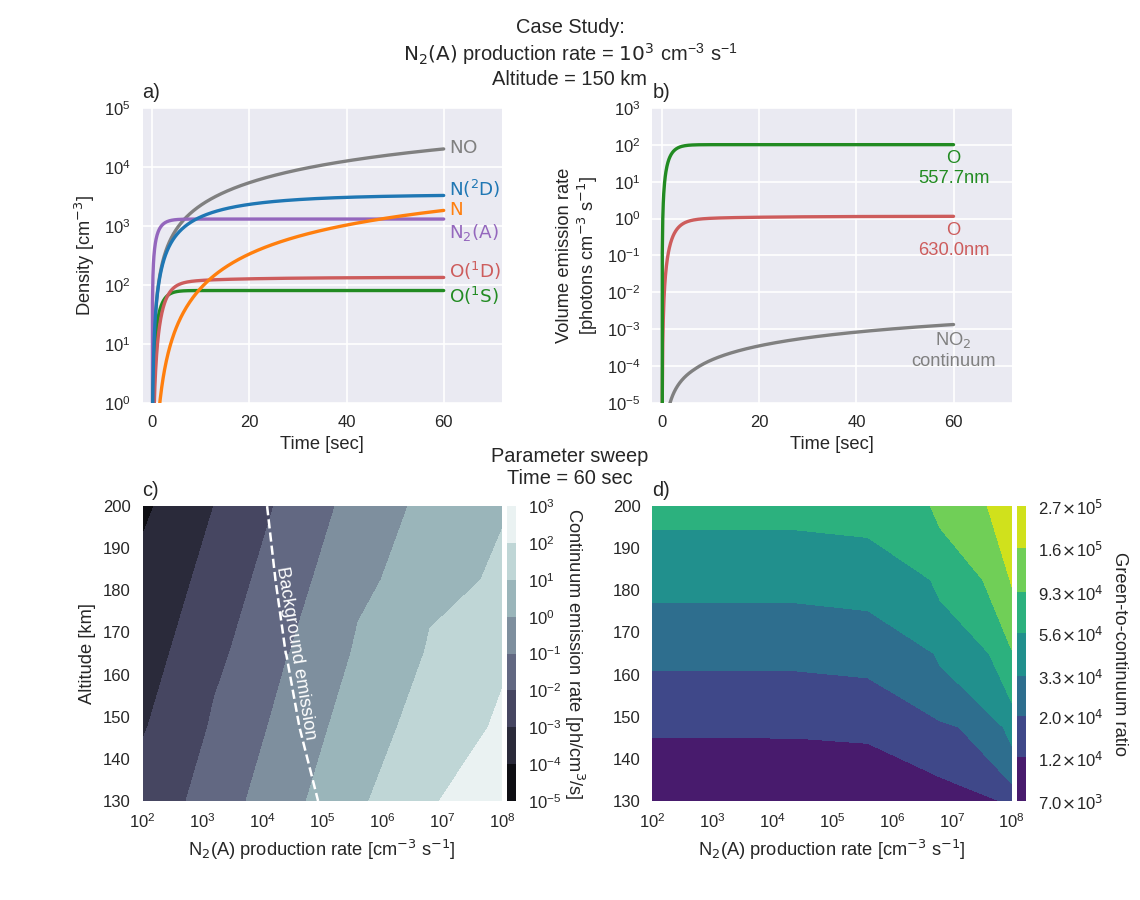

In [9]:
# fig = plt.figure(figsize=(11,7.5))
fig = plt.figure(figsize=(9.5,7.5))

gs = fig.add_gridspec(
    2, 5,
    width_ratios=[1, 0.025, 0.35, 1, 0.025],
    wspace=0.03,   # keep small globally
    hspace=0.35
)

# axes
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,3])

ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,3])

# colorbars
cax3 = fig.add_subplot(gs[1,1])
cax4 = fig.add_subplot(gs[1,4])

#########################################
plt.sca(ax1)

# dsi = ds.sel(rate=1e3, alt=140., method='nearest')
alt = 150
dsi = dsN2A.interp(rate=1e3, alt=alt)
dsi = dsi.sel(time=slice(0,60)) # Only plot first minute for this plot

# dsi.n.sel(species=['N','N(2D)','NO','N2(A)','O(1D)','O(1S)']).plot(hue='species')
plt.plot(dsi.time, dsi.n.sel(species='NO'), color='gray', lw=2)
plt.plot(dsi.time, dsi.n.sel(species='N2(A)'), color='tab:purple', lw=2)
plt.plot(dsi.time, dsi.n.sel(species='O(1S)'), color='forestgreen', lw=2)
plt.plot(dsi.time, dsi.n.sel(species='O(1D)'), color='indianred', lw=2)
plt.plot(dsi.time, dsi.n.sel(species='N'), color='tab:orange', lw=2)
plt.plot(dsi.time, dsi.n.sel(species='N(2D)'), color='tab:blue', lw=2)

fw = 'normal'
fs = 11
plt.text(dsi.time[-1]+1, dsi.n.sel(species='NO').isel(time=-1), r'$\mathrm{NO}$', color='gray', va='center', ha='left', fontsize=fs, fontweight=fw)
plt.text(dsi.time[-1]+1, dsi.n.sel(species='N2(A)').isel(time=-1)*0.6, r'$\mathrm{N_2(A)}$', color='tab:purple', va='center', ha='left', fontsize=fs, fontweight=fw)
plt.text(dsi.time[-1]+1, dsi.n.sel(species='O(1S)').isel(time=-1)*0.8, r'$\mathrm{O(^1S)}$', color='forestgreen', va='center', ha='left', fontsize=fs, fontweight=fw)
plt.text(dsi.time[-1]+1, dsi.n.sel(species='O(1D)').isel(time=-1)*1.3, r'$\mathrm{O(^1D)}$', color='indianred', va='center', ha='left', fontsize=fs, fontweight=fw)
plt.text(dsi.time[-1]+1, dsi.n.sel(species='N').isel(time=-1), r'$\mathrm{N}$', color='tab:orange', va='center', ha='left', fontsize=fs, fontweight=fw)
plt.text(dsi.time[-1]+1, dsi.n.sel(species='N(2D)').isel(time=-1)*1.3, r'$\mathrm{N(^2D)}$', color='tab:blue', va='center', ha='left', fontsize=fs, fontweight=fw)

plt.ylim((1e0,1e5))
plt.xlim((-2,72))
plt.yscale('log')
plt.xlabel('Time [sec]')
plt.ylabel('Density [cm$^{-3}$]')
plt.gcf().suptitle(
    f'Case Study:\n'
    r'$\mathrm{N_2(A)}$ production rate = $10^3\ \mathregular{cm^{-3}\ s^{-1}}$'
    f'\nAltitude = {alt} km'
)


#####################################################
plt.sca(ax2)
plt.plot(dsi.time, dsi.emis.sel(emission='hvcont'), color='gray', lw=2)
plt.plot(dsi.time, dsi.emis.sel(emission='hv6300A'), color='indianred', lw=2)
plt.plot(dsi.time, dsi.emis.sel(emission='hv5577A'), color='forestgreen', lw=2)

plt.text(dsi.time[-1], dsi.emis.sel(emission='hvcont').isel(time=-1)*0.7, 'NO$_2$\ncontinuum', color='gray', va='top', ha='center', fontsize=fs, fontweight=fw)
plt.text(dsi.time[-1], dsi.emis.sel(emission='hv6300A').isel(time=-1)*0.7, 'O\n630.0nm', color='indianred', va='top', ha='center', fontsize=fs, fontweight=fw)
plt.text(dsi.time[-1], dsi.emis.sel(emission='hv5577A').isel(time=-1)*0.7, 'O\n557.7nm', color='forestgreen', va='top', ha='center', fontsize=fs, fontweight=fw)

plt.ylabel('Volume emission rate\n[photons cm$^{-3}$ s$^{-1}$]')
plt.yscale('log')
plt.xlim((-2,72))
plt.ylim((1e-5, 1e3))
plt.xlabel('Time [sec]')



######################################################
plt.sca(ax3)
da = dsN2A.emis.sel(emission='hvcont').isel(time=-1)
Z = da.T.values   # shape must be (alt, rate)
levels = np.logspace(
    np.log10(Z[Z > 0].min()),
    np.log10(Z.max()),
    10
)
vmin = int(np.floor(np.log10(Z.min())))
vmax = int(np.ceil(np.log10(Z.max())))
levels = np.logspace(vmin, vmax, vmax-vmin+1)
cf = plt.contourf(
    dsN2A.rate,
    dsN2A.alt,
    Z,
    levels=levels,
    norm=LogNorm(),
    cmap="bone"
)
plt.xscale('log')
plt.xlabel(r'N$_2$(A) production rate [cm$^{-3}$ s$^{-1}$]')
plt.ylabel('Altitude [km]')

cb = fig.colorbar(cf, cax=cax3)
cb.set_label(r'Continuum emission rate [ph/cm$^3$/s]', rotation=-90, labelpad=15)

e_bg = ds_bg.emis.sel(emission='hvcont')
bg2d = np.tile(e_bg.values[:, None], (1, Z.shape[1]))  # (alt, rate) to match Z

cs = plt.contour(
    dsN2A.rate,
    dsN2A.alt,
    Z - bg2d,
    levels=[0.0],
    colors="w",
    linestyles='--',
    linewidths=1.5
)

plt.clabel(
    cs,
    fmt={0.0: "Background emission\n"},
    inline=False,
    fontsize=11,
    colors="w"
)


#####################################################
plt.sca(ax4)
da = (dsN2A.emis.sel(emission='hv5577A')/dsN2A.emis.sel(emission='hvcont')).isel(time=-1)
Z = da.T.values   # shape must be (alt, rate)

levels = [7e3, 1.2e4, 2e4, 3.3e4, 5.6e4, 9.3e4, 1.6e5, 2.7e5] 

cf = plt.contourf(
    dsN2A.rate,
    dsN2A.alt,
    Z,
    levels=levels,
    norm=LogNorm(),
    cmap="viridis"
)

plt.xscale('log')
plt.xlabel(r'N$_2$(A) production rate [cm$^{-3}$ s$^{-1}$]')
# plt.ylabel('Altitude [km]')
cb = fig.colorbar(cf, cax=cax4, ticks=levels)
cb.set_ticklabels([
    r"7.0$\!\times\!$10$^{3}$",
    r"1.2$\!\times\!$10$^{4}$",
    r"2.0$\!\times\!$10$^{4}$",
    r"3.3$\!\times\!$10$^{4}$",
    r"5.6$\!\times\!$10$^{4}$",
    r"9.3$\!\times\!$10$^{4}$",
    r"1.6$\!\times\!$10$^{5}$",
    r"2.7$\!\times\!$10$^{5}$",
])


cb.set_label(r'Green-to-continuum ratio', rotation=-90, labelpad=15)


fig.text(
    0.5, 0.48,                     # (x, y) in figure coords
    "Parameter sweep\nTime = 300 sec",
    ha="center",
    va="center",
    fontsize=plt.rcParams["axes.titlesize"]
)

for i, ax in enumerate([ax1, ax2, ax3, ax4]):
    plt.text(0.00, 1.02, ['a)', 'b)', 'c)', 'd)'][i], ha='left',  va='bottom', transform=ax.transAxes, fontsize=12)

# plt.tight_layout()
# plt.savefig('/home/bharding/nb/STEVE/PAPER_N2v_2026/paper2026_figures/N2A.pdf', bbox_inches='tight')

# Run 2, monoenergetic

In [6]:
# Low-res for quick testing
# eVs = [1.0, 2.5, 4.1]
eVs = np.arange(0.5, 5.0001, 0.2) 

# High-res used for final figure
# eVs = np.arange(0.5, 5.0001, 0.02) # Use this for final run


alts = [130,200]
duration = 5 * 60  # sec
ne = 1e5
Tn_mult = 1

# Use Gillies event lat, lon, time to initialize using MSIS
lat, lon = 50.998, -107.15
time = pd.to_datetime('2018-04-10 06:30:45')

t1 = datetime.now()

results_alt = []

for alt in alts:
    print(f'alt = {alt} km')

    # --- altitude-dependent background atmosphere ---
    ds_msis = itm_models.msis(time, lat, lon, alt)
    Tn = Tn_mult * ds_msis.TEMPERATURE.item()
    nN2_init = ds_msis.N2.item() / 1e6   # m^-3 to cm^-3
    nO2_init = ds_msis.O2.item() / 1e6   # m^-3 to cm^-3
    nO_init  = ds_msis.O.item()  / 1e6   # m^-3 to cm^-3
    nNO_init = 0

    # Eventually replace this once IRI is implemented. But it will barely matter.
    Ti = Tn
    Te = Tn

    results_energy = []

    for eV in eVs:
        print(f'  {eV:.1f} eV')

        ds_k_eedf = steve_n2v.calculate_rate_coefficients(eV, np.inf, delta_function=1)

        # Note that in all below we are multiplying by rate coef ne, then ignoring e in defining the reaction,
        # since e is acting like a source, not being tracked.
        source_rxs = []

        # N2(v) + e -> N2(v') + e
        k = ne * ds_k_eedf.k_N2_vib
        for v1 in range(N2vib):
            for v2 in range(N2vib):
                kv1v2 = k.sel(vib_state_start=v1, vib_state_end=v2).item()
                if np.isfinite(kv1v2) and v1!=v2:
                    source_rxs.append([f"N2(v={v1}) → N2(v={v2})", kv1v2, 'EEDF', 'nan'])

        # O(1D) excitation
        k = ne * ds_k_eedf.k_electronic
        kO1D = k.sel(el_state='O_1D').item()
        source_rxs.append([f"O → O(1D)", kO1D, 'EEDF', 'nan'])

        # O(1S) excitation
        kO1S = k.sel(el_state='O_1S').item()
        source_rxs.append([f"O → O(1S)", kO1S, 'EEDF', 'nan'])

        # N2 triplet cascade omitted because we are staying below threshold for this plot

        # Put it together into coef dataframe
        rxs = chem_rxs + source_rxs
        df = pd.DataFrame(rxs, columns=['Reaction', 'Rate', 'Src0', 'Src1'])

        species, emissions, din, dout, demis, nin, nout, nemis, sidx, eidx = steve_n2v.reaction_input_output(df)

        steve_n2v.write_reaction_rate_function(df, fn='steve_n2v_reaction.py', Ti='Ti')

        import steve_n2v_reaction
        importlib.reload(steve_n2v_reaction)

        #### Run model
        dsi = run_case(
            nN2_init, nO2_init, nO_init, Tn, Ti, Te,
            duration=duration,
            verbose=False,
            nNO_init=nNO_init,
            max_iters=200000
        )

        results_energy.append(dsi.expand_dims(energy=[eV]))

    ds_alt = xr.concat(results_energy, dim='energy').expand_dims(alt=[alt])
    results_alt.append(ds_alt)

ds = xr.concat(results_alt, dim='alt')

t2 = datetime.now()
print(f'Completed in {(t2-t1).total_seconds()/60} minutes')

alt = 130 km
  0.5 eV
  0.7 eV
  0.9 eV
  1.1 eV
  1.3 eV
  1.5 eV
  1.7 eV
  1.9 eV
  2.1 eV
  2.3 eV
  2.5 eV
  2.7 eV
  2.9 eV
  3.1 eV
  3.3 eV
  3.5 eV
  3.7 eV
  3.9 eV
  4.1 eV
  4.3 eV
  4.5 eV
  4.7 eV
  4.9 eV
alt = 200 km
  0.5 eV
  0.7 eV
  0.9 eV
  1.1 eV
  1.3 eV
  1.5 eV
  1.7 eV
  1.9 eV
  2.1 eV
  2.3 eV
  2.5 eV
  2.7 eV
  2.9 eV
  3.1 eV
  3.3 eV
  3.5 eV
  3.7 eV
  3.9 eV
  4.1 eV
  4.3 eV
  4.5 eV
  4.7 eV
  4.9 eV
Completed in 17.19897286666667 minutes


#### A second run at 3 x MSIS temperatures

In [7]:

Tn_mult = 3

t1 = datetime.now()

results_alt = []

for alt in alts:
    print(f'alt = {alt} km')

    # --- altitude-dependent background atmosphere ---
    ds_msis = itm_models.msis(time, lat, lon, alt)
    Tn = Tn_mult * ds_msis.TEMPERATURE.item()
    nN2_init = ds_msis.N2.item() / 1e6   # m^-3 to cm^-3
    nO2_init = ds_msis.O2.item() / 1e6   # m^-3 to cm^-3
    nO_init  = ds_msis.O.item()  / 1e6   # m^-3 to cm^-3
    # nNO_init = ds_msis.NO.item()/1e6
    nNO_init = 0

    # Eventually replace this once IRI is implemented. But it will barely matter.
    Ti = Tn
    Te = Tn

    results_energy = []

    for eV in eVs:
        print(f'  {eV:.1f} eV')

        ds_k_eedf = steve_n2v.calculate_rate_coefficients(eV, np.inf, delta_function=1)

        # Note that in all below we are multiplying by rate coef ne, then ignoring e in defining the reaction,
        # since e is acting like a source, not being tracked.
        source_rxs = []

        # N2(v) + e -> N2(v') + e
        k = ne * ds_k_eedf.k_N2_vib
        for v1 in range(N2vib):
            for v2 in range(N2vib):
                kv1v2 = k.sel(vib_state_start=v1, vib_state_end=v2).item()
                if np.isfinite(kv1v2) and v1!=v2:
                    source_rxs.append([f"N2(v={v1}) → N2(v={v2})", kv1v2, 'EEDF', 'nan'])

        # O(1D) excitation
        k = ne * ds_k_eedf.k_electronic
        kO1D = k.sel(el_state='O_1D').item()
        source_rxs.append([f"O → O(1D)", kO1D, 'EEDF', 'nan'])

        # O(1S) excitation
        kO1S = k.sel(el_state='O_1S').item()
        source_rxs.append([f"O → O(1S)", kO1S, 'EEDF', 'nan'])

        # N2 triplet cascade omitted because we are staying below threshold for this plot

        # Put it together into coef dataframe
        rxs = chem_rxs + source_rxs
        df = pd.DataFrame(rxs, columns=['Reaction', 'Rate', 'Src0', 'Src1'])

        species, emissions, din, dout, demis, nin, nout, nemis, sidx, eidx = steve_n2v.reaction_input_output(df)

        steve_n2v.write_reaction_rate_function(df, fn='steve_n2v_reaction.py', Ti='Ti')

        import steve_n2v_reaction
        importlib.reload(steve_n2v_reaction)

        #### Run model
        dsi = run_case(
            nN2_init, nO2_init, nO_init, Tn, Ti, Te,
            duration=duration,
            verbose=False,
            nNO_init=nNO_init,
            max_iters=200000
        )

        results_energy.append(dsi.expand_dims(energy=[eV]))

    ds_alt = xr.concat(results_energy, dim='energy').expand_dims(alt=[alt])
    results_alt.append(ds_alt)

ds3 = xr.concat(results_alt, dim='alt')

t2 = datetime.now()
print(f'Completed in {(t2-t1).total_seconds()/60} minutes')

alt = 130 km
  0.5 eV
  0.7 eV
  0.9 eV
  1.1 eV
  1.3 eV
  1.5 eV
  1.7 eV
  1.9 eV
  2.1 eV
  2.3 eV
  2.5 eV
  2.7 eV
  2.9 eV
  3.1 eV
  3.3 eV
  3.5 eV
  3.7 eV
  3.9 eV
  4.1 eV
  4.3 eV
  4.5 eV
  4.7 eV
  4.9 eV
alt = 200 km
  0.5 eV
  0.7 eV
  0.9 eV
  1.1 eV
  1.3 eV
  1.5 eV
  1.7 eV
  1.9 eV
  2.1 eV
  2.3 eV
  2.5 eV
  2.7 eV
  2.9 eV
  3.1 eV
  3.3 eV
  3.5 eV
  3.7 eV
  3.9 eV
  4.1 eV
  4.3 eV
  4.5 eV
  4.7 eV
  4.9 eV
Completed in 16.272204283333334 minutes


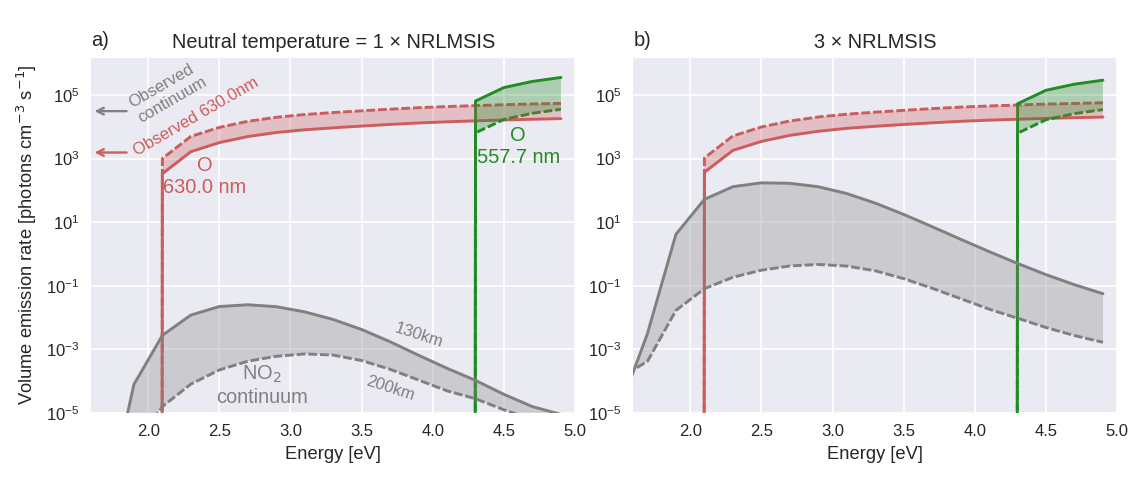

In [8]:
## Version with Gillies reference

plt.figure(figsize=(9.5,4))
from matplotlib.colors import LogNorm

emissions_to_plot = ['hv6300A','hv5577A','hvcont']
colors = ['indianred','forestgreen','gray']
names = ['','','']

titles = ['Neutral temperature = 1 × NRLMSIS', '3 × NRLMSIS']

axs = []
for i, dsa in enumerate([ds, ds3]):

    plt.subplot(1,2,i+1)
    ax = plt.gca()
    axs.append(ax)

    for j in range(len(emissions_to_plot)):
        e = dsa.emis.isel(time=-1).sel(emission=emissions_to_plot[j]).isel(alt=[0,-1])

        plt.fill_between(
            e.energy,
            e.isel(alt=0),
            e.isel(alt=1),
            facecolor=colors[j],
            alpha=0.3, zorder=6
        )
        
        plt.plot(e.energy, e.isel(alt=0), color=colors[j], zorder=5)
        plt.plot(e.energy, e.isel(alt=1), color=colors[j], zorder=5, dashes=(3,1))
        

    if i==0:
        fs = 12
        plt.text(2.4, 85, 'O\n630.0 nm', color=colors[0], fontsize=fs, ha='center')
        plt.text(4.6, 700, 'O\n557.7 nm', color=colors[1], fontsize=fs, ha='center')
        plt.text(2.8, 2e-5, 'NO$_2$\ncontinuum', color=colors[2], fontsize=fs, ha='center')


        # Add Gillies reference radiance, assuming some layer thickness
        assumed_thickness = 50 # km
        y_gillies_cont = 1e-1 * assumed_thickness * 6200
        y_gillies_red  = 0.05 * y_gillies_cont
        

        for y, label, col in [
            (y_gillies_red, 'Observed 630.0nm', colors[0]),
            (y_gillies_cont, 'Observed\ncontinuum', colors[2]),
        ]:
        
            ax.annotate(
                '',
                xy=(0, y),
                xycoords=('axes fraction', 'data'),
                xytext=(0.08, y),
                textcoords=('axes fraction', 'data'),
                arrowprops=dict(
                    arrowstyle='->',
                    lw=1.4,
                    color=col
                )
            )
        
            ax.text(
                0.09, y,
                label,
                transform=ax.get_yaxis_transform(),
                ha='left',
                va='center',
                rotation=30,
                rotation_mode='anchor',
                color=col,
                fontsize=10
            )


        plt.text(3.7, 5.8e-5, '200km', fontsize=10, color=colors[2], va='center', ha='center', rotation=-18)
        plt.text(3.9, 2.8e-3, '130km', fontsize=10, color=colors[2], va='center', ha='center', rotation=-18)

    plt.yscale('log')
    plt.xlim((1.6,5))
    plt.ylim((1e-5,1.5e6))
    plt.xlabel('Energy [eV]')
    if i == 0:
        plt.ylabel('Volume emission rate [photons cm$^{-3}$ s$^{-1}$]')
    plt.title(titles[i])


for i, ax in enumerate(axs):
    plt.text(0.00, 1.02, ['a)', 'b)'][i], ha='left',  va='bottom', transform=ax.transAxes, fontsize=12)


# plt.tight_layout(rect=[0,0,1,0.95])
plt.subplots_adjust(left=0.08, right=0.98, bottom=0.14, top=0.88, wspace=0.12)
# plt.savefig('/home/bharding/nb/STEVE/PAPER_N2v_2026/paper2026_figures/mono.pdf', bbox_inches='tight')

# Run 3: E-parallel-driven EEDFs from BOLSIG+

In [14]:
importlib.reload(steve_n2v)

<module 'steve_n2v' from '/home/bharding/nb/STEVE/PAPER_N2v_2026/Github_standalone_code/steve_n2v.py'>

In [15]:
# Read BOLSIG+ Output file
eedf = steve_n2v.read_BOLSIG(energy_bins=1000)

In [18]:
# Select reasonable ranges for actual run
eedf_run = eedf.sel(alt=[130,200], Epar = slice(0,90)) # reasonable ranges

# Optional downselect along Epar dimension, only for testing. (Comment this to get publication figure)
# eedf_run = eedf_run.isel(Epar = slice(None,None,40)) 
eedf_run = eedf_run.isel(Epar = slice(None,None,10)) 

In [19]:
duration = 5*60  # sec
Tmult = 3     # MSIS multiplier for temperature
ne = 1e5      # what to use here?


# Run MSIS
lat, lon = 50.998, -107.15
time = pd.to_datetime('2018-04-10 06:30:45')
ds_msis = itm_models.msis(time, lat, lon, eedf_run.alt)
Tn = Tmult * ds_msis.TEMPERATURE.values
nN2_init = ds_msis.N2.values / 1e6  # m^-3 to cm^-3
nO2_init = ds_msis.O2.values / 1e6
nO_init = ds_msis.O.values / 1e6
# nNO_init = ds_msis.NO.values / 1e6
nNO_init = 0*nO_init

Ti = Tn
Te = Tn

# Create empty container for results
results = []

t1 = datetime.now()

for i, alt in enumerate(eedf_run.alt):
    row = []
    for j, Epar in enumerate(eedf_run.Epar):
        
        eedfij = eedf_run.isel(alt=i, Epar=j)

        print(f'Running alt={eedfij.alt.item()} Epar={eedfij.Epar.item()}...')

        ################### Calculate rate coefficients for EEDF sources
        ################## (TODO: functionaize this? Or otherwise consolidate? It's clunky to handle by updating .py file each time)
        ds_k_eedf = steve_n2v.calculate_rate_coefficients(eedfij.energy.values, eedfij.values, delta_function=0)
        
        # Note that in all below we are multiplying by rate coef ne, then ignoring e in defining the reaction, 
        # since e is acting like a source, not being tracked.
        source_rxs = []
        
        # N2(v) + e -> N2(v') + e
        k = ne * ds_k_eedf.k_N2_vib
        for v1 in range(N2vib):
            for v2 in range(N2vib):
                kv1v2 = k.sel(vib_state_start = v1, vib_state_end = v2).item()
                if np.isfinite(kv1v2) and v1!=v2:
                    source_rxs.append([f"N2(v={v1}) → N2(v={v2})", kv1v2, 'EEDF','nan'])
            
        # O(1D) excitation
        k = ne * ds_k_eedf.k_electronic
        kO1D = k.sel(el_state='O_1D').item()
        source_rxs.append([f"O → O(1D)", kO1D, 'EEDF','nan'])
        
        # O(1S) excitation
        kO1S = k.sel(el_state='O_1S').item()
        source_rxs.append([f"O → O(1S)", kO1S, 'EEDF','nan'])
        
        # N2 triplet cascade. Do separately for each v. Assume same as ground-state excitation
        kN2_A3  = k.sel(el_state='N2_A3').item()
        kN2_B3  = k.sel(el_state='N2_B3').item()
        kN2_Bp3 = k.sel(el_state='N2_Bp3').item()
        kN2_W3  = k.sel(el_state='N2_W3').item()
        kN2_C3  = k.sel(el_state='N2_C3').item()
        for v in range(N2vib):
            # Two reactions, one for direct N2(A) excitation, and one for cascade from above
            # Direct
            source_rxs.append([f"N2(v={v}) → N2(A)", kN2_A3, 'EEDF','nan'])
            # Cascade: N2 + e --> N2(B and higher) --> N2(B) + (maybe hv, not being tracked) --> N2(A) + hvN2_1P.
            kcasc = kN2_B3 + kN2_Bp3 + kN2_W3 + 0.5*kN2_C3 #0.5 is from branching ratio for predissociation of C state
            source_rxs.append([f"N2(v={v}) → N2(A) + hvN21P", kcasc, 'EEDF','nan'])

        # Put it together into coef dataframe
        rxs = chem_rxs + source_rxs
        df = pd.DataFrame(rxs, columns = ['Reaction','Rate','Src0','Src1'])

        species, emissions, din, dout, demis, nin, nout, nemis, sidx, eidx = steve_n2v.reaction_input_output(df)

        steve_n2v.write_reaction_rate_function(df, fn='steve_n2v_reaction.py', Ti='Ti')
        
        import steve_n2v_reaction
        importlib.reload(steve_n2v_reaction)

        

        # print(f'Initialized. Running model... ')
        #### Run model
        dsi = run_case(
            nN2_init[i], nO2_init[i], nO_init[i],
            Tn[i], Ti[i], Te[i],
            duration=duration,
            verbose=False,
            nNO_init=nNO_init[i],
            max_iters=200000
        )

        row.append(dsi.expand_dims(Epar=[Epar]))  # attach Epar dimension

    ds_alt = xr.concat(row, dim='Epar').expand_dims(alt=[alt])
    results.append(ds_alt)

# Combine all altitude slices into one dataset
dseedf = xr.concat(results, dim='alt')

t2 = datetime.now()
print(f'Completed in {(t2-t1).total_seconds()/60} minutes')

Running alt=130 Epar=1.002...
Running alt=130 Epar=41.08...
Running alt=130 Epar=81.16...
Running alt=200 Epar=1.002...
Running alt=200 Epar=41.08...
Running alt=200 Epar=81.16...
Completed in 2.70559765 minutes


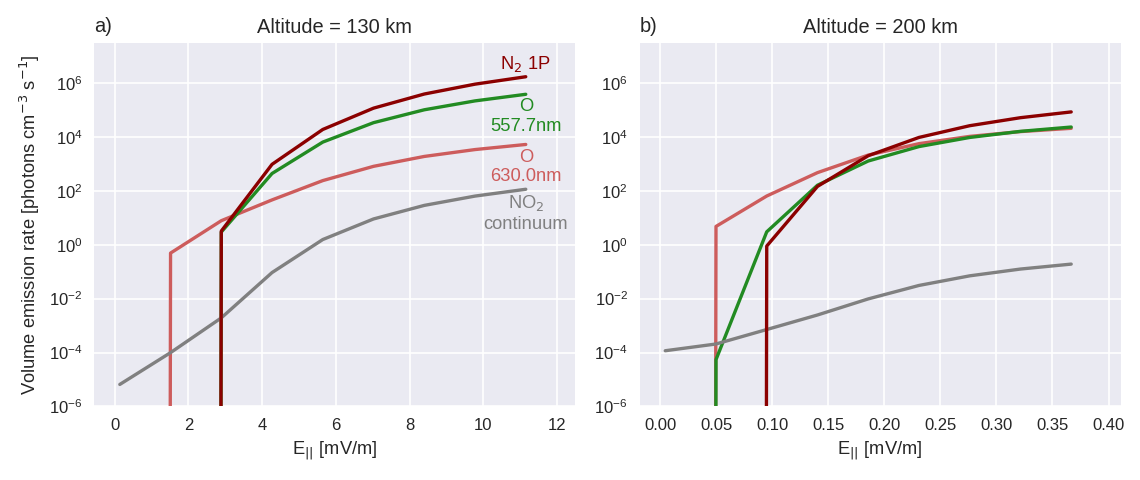

In [13]:
# plt.figure(figsize=(8,4))
plt.figure(figsize=(9.5,4))

from matplotlib.colors import LogNorm

emissions_to_plot = ['hv6300A','hv5577A','hvcont','hvN21P']
colors = ['indianred','forestgreen','gray','darkred']
names = ['','','','','','']

titles = ['alt = 0', 'alt = 1']

dsa = dseedf.sel(Epar=slice(0,85))
axs = []
for spi, alt_i in enumerate([0, 1]):
    
    plt.subplot(1,2,spi+1)
    axs.append(plt.gca())
    
    n0 = dsa.n.isel(time=0, alt=alt_i, Epar=0).sum(dim='species') # neutral density
    x = dsa.Epar * 1e-17*n0 * 1e2 * 1e3 # Td to V cm2, to V/cm, to V/m, to mV/m    

    for j, em in enumerate(emissions_to_plot):
        e = dsa.emis.isel(time=-1).sel(emission=em).isel(alt=[0,-1])

        
        plt.plot(
            x,
            e.isel(alt=alt_i),
            color=colors[j],
            label=em,
            lw = 2
        )

    plt.yscale('log')
    plt.ylim((1e-6,3e7))
    xmx = x.max()
    plt.xlim((-0.05*xmx, 1.12*xmx))
    plt.xlabel('E$_{||}$ [mV/m]')
    
    if spi == 0:
        fs = 11
        fw = 'normal'
        plt.ylabel('Volume emission rate [photons cm$^{-3}$ s$^{-1}$]')

        plt.text(x.isel(Epar=-1), dsa.emis.isel(time=-1, alt=alt_i, Epar=-1).sel(emission='hvcont')*0.7, 'NO$_2$\ncontinuum', 
                 color=colors[2], va='top', ha='center', fontsize=fs, fontweight=fw)
        plt.text(x.isel(Epar=-1), dsa.emis.isel(time=-1, alt=alt_i, Epar=-1).sel(emission='hv6300A')*0.7, 'O\n630.0nm', 
                 color=colors[0], va='top', ha='center', fontsize=fs, fontweight=fw)
        plt.text(x.isel(Epar=-1), dsa.emis.isel(time=-1, alt=alt_i, Epar=-1).sel(emission='hv5577A')*0.7, 'O\n557.7nm', 
                 color=colors[1], va='top', ha='center', fontsize=fs, fontweight=fw)
        plt.text(x.isel(Epar=-1), dsa.emis.isel(time=-1, alt=alt_i, Epar=-1).sel(emission='hvN21P')*1.3, 'N$_2$ 1P', 
                 color=colors[3], va='bottom', ha='center', fontsize=fs, fontweight=fw)

    plt.title(f'Altitude = {e.isel(alt=alt_i).alt.item()} km')

plt.tight_layout()
for i, ax in enumerate(axs):
    plt.text(0.00, 1.02, ['a)', 'b)'][i], ha='left',  va='bottom', transform=ax.transAxes, fontsize=12)


# plt.savefig('/home/bharding/nb/STEVE/PAPER_N2v_2026/paper2026_figures/Epar.pdf', bbox_inches='tight')